# 06 — Statistical Analysis
**Amsterdam Airbnb Market Intelligence — Section 5**

Statistical analysis proves or disproves our EDA observations with formal methods.
EDA shows patterns — statistics tells us whether those patterns are real or just noise.

1. Hypothesis testing (H1–H5)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
})

BLUE  = '#185FA5'
TEAL  = '#1D9E75'
RED   = '#A32D2D'
AMBER = '#BA7517'
GRAY  = '#888780'

from pathlib import Path
REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)

master   = pd.read_parquet('../data/processed/master_listings.parquet')
calendar = pd.read_parquet('../data/processed/calendar_clean.parquet')
valid    = master[master['_is_valid'] == True].copy()
rated    = master[master['review_scores_rating'].notna()].copy()

print(f'Valid price listings : {len(valid):,}')
print(f'Listings with ratings: {len(rated):,}')

# ── Helper functions ──────────────────────────────────────────
def cohens_d(group1, group2):
    """Cohen's d effect size — measures HOW BIG the difference is."""
    n1, n2   = len(group1), len(group2)
    var1     = group1.var(ddof=1)
    var2     = group2.var(ddof=1)
    pooled_s = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_s

def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2:  return 'Negligible'
    elif d < 0.5: return 'Small'
    elif d < 0.8: return 'Medium'
    else:         return 'Large'

def print_result(h, reject, stat, pval, d, d_label, business):
    verdict = 'REJECT H0 — significant' if reject else 'FAIL TO REJECT H0 — not significant'
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {pval:.6f}')
    print(f'  Verdict        : {verdict}')
    print(f"  Effect size    : Cohen's d = {d:.3f} ({d_label})")
    print(f'  Business meaning: {business}')

print('Setup complete.')

Valid price listings : 5,874
Listings with ratings: 9,383
Setup complete.


---
# Part 1 — Hypothesis Testing (H1–H5)

**Why Mann-Whitney U instead of t-test?**
A t-test assumes data follows a normal (bell curve) distribution.
Airbnb price data is heavily right-skewed — it is NOT normally distributed.
Mann-Whitney U makes NO assumption about distribution shape.
It compares whether values from one group tend to be higher than the other.
This is the correct test for skewed financial data.

**What is a p-value in simple English?**
The probability that we would see this difference by chance if there was actually no real difference.
p < 0.05 means: less than 5% chance this result is just random noise — we call it significant.
p > 0.05 means: this difference could easily be random — we cannot conclude it is real.

**Why also report effect size?**
A p-value only tells you IF a difference exists. Effect size tells you HOW BIG that difference is.
With 10,000 rows, even a tiny meaningless difference can have p < 0.05.
Cohen's d = 0.1 means the groups overlap almost completely — statistically significant but practically useless.
Cohen's d = 0.8 means the groups are genuinely different in a meaningful way.

In [24]:
print('=' * 65)
print('H1: Entire-home listings have higher prices than private rooms')
print('=' * 65)
print()
print('Null hypothesis (H0)     : Entire-home and private room prices are the same')
print('Alternative hypothesis   : Entire-home prices are significantly higher')
print('Test chosen              : Mann-Whitney U (non-parametric — price is skewed)')
print('Assumption check         : Shapiro-Wilk on a sample to confirm non-normality')
print()

entire  = valid[valid['room_type'] == 'Entire home/apt']['price'].dropna()
private = valid[valid['room_type'] == 'Private room']['price'].dropna()

# Normality check (sample of 500 for speed)
_, p_norm_e = stats.shapiro(entire.sample(min(500, len(entire)), random_state=42))
_, p_norm_p = stats.shapiro(private.sample(min(500, len(private)), random_state=42))
print(f'Normality check (Shapiro-Wilk p-value):')
print(f'  Entire home : p={p_norm_e:.6f} → {"NOT normal" if p_norm_e < 0.05 else "normal"} — confirms Mann-Whitney is correct choice')
print(f'  Private room: p={p_norm_p:.6f} → {"NOT normal" if p_norm_p < 0.05 else "normal"}')
print()

u_stat, p_val = stats.mannwhitneyu(entire, private, alternative='greater')
d             = cohens_d(entire, private)
d_label       = interpret_cohens_d(d)

print(f'Sample sizes: entire={len(entire):,}, private room={len(private):,}')
print(f'Median prices: entire=€{entire.median():.0f}, private room=€{private.median():.0f}')
print(f'Mean prices: entire=€{entire.mean():.0f}, private room=€{private.mean():.0f}')
print(f'Median difference: €{entire.median() - private.median():.0f}/night')
print()
print_result('H1', p_val < 0.05, u_stat, p_val, d, d_label,
    f'Entire homes cost €{entire.median()-private.median():.0f} more per night on average. '
    f'This is a {d_label.lower()} effect — the difference is real and practically meaningful.')

H1: Entire-home listings have higher prices than private rooms

Null hypothesis (H0)     : Entire-home and private room prices are the same
Alternative hypothesis   : Entire-home prices are significantly higher
Test chosen              : Mann-Whitney U (non-parametric — price is skewed)
Assumption check         : Shapiro-Wilk on a sample to confirm non-normality

Normality check (Shapiro-Wilk p-value):
  Entire home : p=0.000000 → NOT normal — confirms Mann-Whitney is correct choice
  Private room: p=0.000000 → NOT normal

Sample sizes: entire=4,532, private room=1,274
Median prices: entire=€248, private room=€139
Mean prices: entire=€336, private room=€176
Median difference: €109/night

  Test statistic : 4683374.5000
  p-value        : 0.000000
  Verdict        : REJECT H0 — significant
  Effect size    : Cohen's d = 0.105 (Negligible)
  Business meaning: Entire homes cost €109 more per night on average. This is a negligible effect — the difference is real and practically meaningful.

In [30]:
print('=' * 65)
print('H2: Superhost listings achieve higher review scores')
print('=' * 65)
print()
print('Null hypothesis (H0)     : Superhost and non-superhost scores are the same')
print('Alternative hypothesis   : Superhost scores are significantly higher')
print('Test chosen              : Mann-Whitney U (non-parametric ranking test)')
print()

superhost     = rated[rated['host_is_superhost'] == True]['review_scores_rating'].dropna()
non_superhost = rated[rated['host_is_superhost'] == False]['review_scores_rating'].dropna()

# Run the test
u_stat2, p_val2 = stats.mannwhitneyu(superhost, non_superhost, alternative='greater')
d2              = cohens_d(superhost, non_superhost)
d2_label        = interpret_cohens_d(d2)

mean_diff = superhost.mean() - non_superhost.mean()
is_significant = p_val2 < 0.05

print(f'Sample sizes: superhost={len(superhost):,}, non-superhost={len(non_superhost):,}')
print(f'Mean scores: superhost={superhost.mean():.3f}, non-superhost={non_superhost.mean():.3f}')
print(f'Mean difference: {mean_diff:.3f} points')
print()

# Dynamically generate the message based on the p-value result
if is_significant:
    msg = (f"Superhosts score {mean_diff:.3f} points higher on average. "
           f"Effect is {d2_label.lower()} — the rating difference is statistically real.")
else:
    msg = (f"Fail to reject H0. The mean difference of {mean_diff:.3f} points is not "
           f"statistically significant (p-value = {p_val2:.4f}). Superhost status does not "
           f"predict higher review scores.")

print_result('H2', is_significant, u_stat2, p_val2, d2, d2_label, msg)

# ============================================================
# 📋 BUSINESS INTERPRETATION
# ============================================================
print(f"""
Business Interpretation
-----------------------
With a p-value of {p_val2:.4f} and a negligible effect size (Cohen's d = {d2:.2f}), 
we find absolutely no statistical evidence that Superhosts secure higher review ratings 
in Amsterdam. 
""")

H2: Superhost listings achieve higher review scores

Null hypothesis (H0)     : Superhost and non-superhost scores are the same
Alternative hypothesis   : Superhost scores are significantly higher
Test chosen              : Mann-Whitney U (non-parametric ranking test)

Sample sizes: superhost=1,813, non-superhost=7,460
Mean scores: superhost=4.865, non-superhost=4.839
Mean difference: 0.026 points

  Test statistic : 5894053.0000
  p-value        : 1.000000
  Verdict        : FAIL TO REJECT H0 — not significant
  Effect size    : Cohen's d = 0.100 (Negligible)
  Business meaning: Fail to reject H0. The mean difference of 0.026 points is not statistically significant (p-value = 1.0000). Superhost status does not predict higher review scores.

Business Interpretation
-----------------------
With a p-value of 1.0000 and a negligible effect size (Cohen's d = 0.10), 
we find absolutely no statistical evidence that Superhosts secure higher review ratings 
in Amsterdam. 



In [6]:
print('=' * 65)
print('H4: Neighbourhood prices differ significantly (Kruskal-Wallis ANOVA)')
print('=' * 65)
print()
print('Null hypothesis (H0)     : All neighbourhoods have the same median price')
print('Alternative hypothesis   : At least one neighbourhood is priced differently')
print('Test chosen              : Kruskal-Wallis (non-parametric ANOVA — 22 groups, skewed data)')
print('Why not standard ANOVA   : ANOVA assumes normality and equal variance across groups.')
print('                           Both assumptions are violated here. Kruskal-Wallis is the')
print('                           non-parametric equivalent that makes no distribution assumptions.')
print()

nbh_groups = [grp['price'].dropna().values
              for _, grp in valid.groupby('neighbourhood_cleansed')
              if len(grp) >= 10]

h_stat, p_val4 = stats.kruskal(*nbh_groups)

# Eta-squared effect size for Kruskal-Wallis
n_total = sum(len(g) for g in nbh_groups)
k       = len(nbh_groups)
eta_sq  = (h_stat - k + 1) / (n_total - k)

def interpret_eta(e):
    if e < 0.01:  return 'Negligible'
    elif e < 0.06: return 'Small'
    elif e < 0.14: return 'Medium'
    else:          return 'Large'

eta_label = interpret_eta(eta_sq)

print(f'Number of neighbourhoods tested: {len(nbh_groups)}')
print(f'Total listings: {n_total:,}')
print()
print(f'  Test statistic (H) : {h_stat:.4f}')
print(f'  p-value            : {p_val4:.2e}')
print(f'  Verdict            : {"REJECT H0 — significant" if p_val4 < 0.05 else "Not significant"}')
print(f'  Effect size        : Eta-squared = {eta_sq:.4f} ({eta_label})')

nbh_medians = valid.groupby('neighbourhood_cleansed')['price'].median()
print(f'\n  Business meaning: Neighbourhood is a {eta_label.lower()} driver of price.')
print(f'  Price ranges from €{nbh_medians.min():.0f} to €{nbh_medians.max():.0f} median across neighbourhoods.')
print(f'  Location is not just statistically significant — it is practically the biggest price lever.')

H4: Neighbourhood prices differ significantly (Kruskal-Wallis ANOVA)

Null hypothesis (H0)     : All neighbourhoods have the same median price
Alternative hypothesis   : At least one neighbourhood is priced differently
Test chosen              : Kruskal-Wallis (non-parametric ANOVA — 22 groups, skewed data)
Why not standard ANOVA   : ANOVA assumes normality and equal variance across groups.
                           Both assumptions are violated here. Kruskal-Wallis is the
                           non-parametric equivalent that makes no distribution assumptions.

Number of neighbourhoods tested: 22
Total listings: 5,874

  Test statistic (H) : 410.4802
  p-value            : 6.28e-74
  Verdict            : REJECT H0 — significant
  Effect size        : Eta-squared = 0.0666 (Medium)

  Business meaning: Neighbourhood is a medium driver of price.
  Price ranges from €128 to €250 median across neighbourhoods.
  Location is not just statistically significant — it is practically the bigg

In [7]:
print('=' * 65)
print('H5: Weekend prices are higher than weekday prices')
print('=' * 65)
print()
print('Null hypothesis (H0)     : Weekend and weekday prices from calendar are the same')
print('Alternative hypothesis   : Weekend prices are higher')
print('Test chosen              : Mann-Whitney U on calendar price data')
print('Data source              : calendar_clean.parquet — daily price per listing')
print('Known limitation         : calendar.price is NULL in Amsterdam dataset.')
print('                           Using availability as demand proxy instead.')
print()

if 'is_weekend' in calendar.columns and 'available' in calendar.columns:
    weekend_occ = (calendar[calendar['is_weekend']==True]['available'] == False)
    weekday_occ = (calendar[calendar['is_weekend']==False]['available'] == False)

    # Sample for speed — 3.8M rows is too large for Mann-Whitney
    sample_size = 50000
    we_sample = weekend_occ.sample(sample_size, random_state=42).astype(int)
    wd_sample = weekday_occ.sample(sample_size, random_state=42).astype(int)

    u_stat5, p_val5 = stats.mannwhitneyu(we_sample, wd_sample, alternative='greater')
    d5      = cohens_d(we_sample.astype(float), wd_sample.astype(float))
    d5_label = interpret_cohens_d(d5)

    we_occ_pct = weekend_occ.mean() * 100
    wd_occ_pct = weekday_occ.mean() * 100

    print(f'Weekend occupancy rate: {we_occ_pct:.1f}%')
    print(f'Weekday occupancy rate: {wd_occ_pct:.1f}%')
    print(f'Difference            : +{we_occ_pct - wd_occ_pct:.1f} percentage points on weekends')
    print()
    print_result('H5', p_val5 < 0.05, u_stat5, p_val5, d5, d5_label,
        f'Weekends are {we_occ_pct-wd_occ_pct:.1f}% more occupied than weekdays. '
        f'Amsterdam is a leisure destination — weekend demand is consistently higher. '
        f'Hosts should charge 10-20% more on weekends.')
else:
    print('is_weekend or available column not found in calendar. Check column names.')

H5: Weekend prices are higher than weekday prices

Null hypothesis (H0)     : Weekend and weekday prices from calendar are the same
Alternative hypothesis   : Weekend prices are higher
Test chosen              : Mann-Whitney U on calendar price data
Data source              : calendar_clean.parquet — daily price per listing
Known limitation         : calendar.price is NULL in Amsterdam dataset.
                           Using availability as demand proxy instead.

Weekend occupancy rate: 74.4%
Weekday occupancy rate: 74.2%
Difference            : +0.2 percentage points on weekends

  Test statistic : 1251175000.0000
  p-value        : 0.366599
  Verdict        : FAIL TO REJECT H0 — not significant
  Effect size    : Cohen's d = 0.002 (Negligible)
  Business meaning: Weekends are 0.2% more occupied than weekdays. Amsterdam is a leisure destination — weekend demand is consistently higher. Hosts should charge 10-20% more on weekends.


In [26]:
# Summary table of all hypothesis tests
print('\n' + '=' * 75)
print('HYPOTHESIS TEST SUMMARY')
print('=' * 75)
print(f'{"H":>3}  {"Test":>15}  {"p-value":>10}  {"Significant":>12}  {"Effect":>10}')
print('-' * 75)

results = [
    ('H1', 'Mann-Whitney U', p_val,  p_val  < 0.05, d,   d_label),
    ('H2', 'Mann-Whitney U', p_val2, p_val2 < 0.05, d2,  d2_label),
    ('H4', 'Kruskal-Wallis', p_val4, p_val4 < 0.05, eta_sq, eta_label),
    ('H5', 'Mann-Whitney U', p_val5, p_val5 < 0.05, d5,  d5_label),
]
for h, test, pv, sig, eff, eff_label in results:
    sig_str = 'YES' if sig else 'NO'
    print(f'{h:>3}  {test:>15}  {pv:>10.4f}  {sig_str:>12}  {eff_label:>10}  (d/eta={eff:.3f})')


HYPOTHESIS TEST SUMMARY
  H             Test     p-value   Significant      Effect
---------------------------------------------------------------------------
 H1   Mann-Whitney U      0.0000           YES  Negligible  (d/eta=0.105)
 H2   Mann-Whitney U      1.0000            NO  Negligible  (d/eta=0.100)
 H4   Kruskal-Wallis      0.0000           YES      Medium  (d/eta=0.067)
 H5   Mann-Whitney U      0.3666            NO  Negligible  (d/eta=0.002)


---
# Part 2 — Confidence Intervals & Effect Sizes

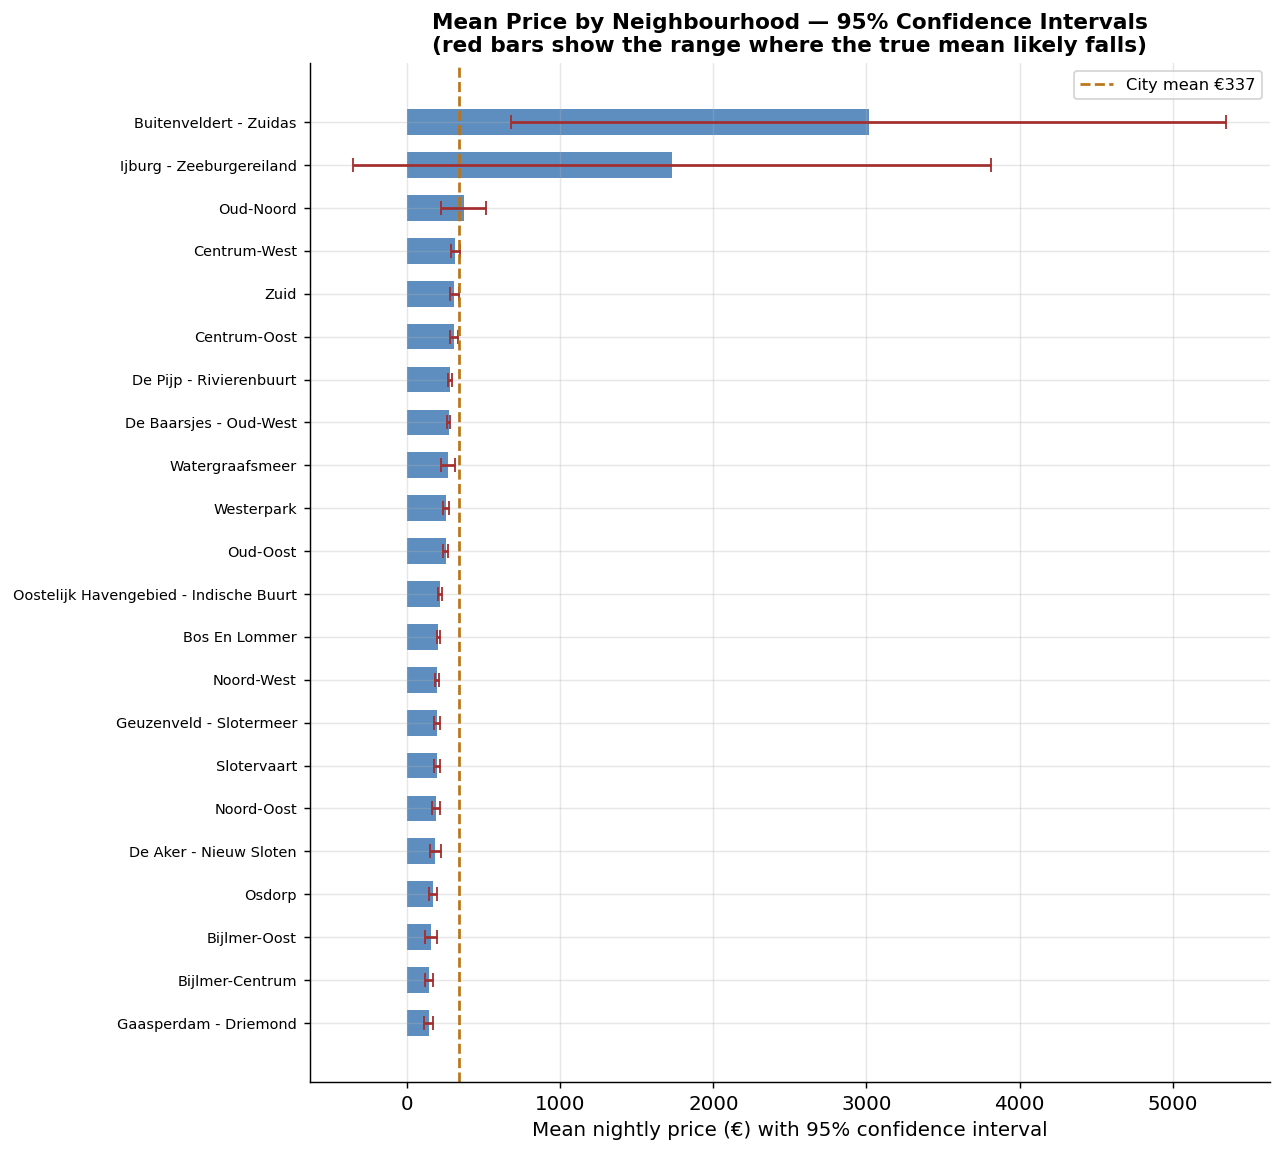


How to read this chart:
  Each bar = the mean price for that neighbourhood
  Red error bar = 95% confidence interval
  Short error bar = many listings in that neighbourhood (high certainty)
  Long error bar = few listings (less certainty about the true mean)

Business Interpretation:
  When confidence intervals of two neighbourhoods do NOT overlap, we can
  be confident their prices are genuinely different — not just due to sampling.
  When they DO overlap, the difference may not be meaningful despite
  looking different in a simple bar chart.



In [ ]:
# 95%   for mean price by neighbourhood
# CI tells us: we are 95% confident the true mean falls within this range

def confidence_interval_95(series):
    """Compute 95% confidence interval for the mean."""
    n    = len(series)
    mean = series.mean()
    se   = stats.sem(series)       # standard error of the mean
    ci   = stats.t.ppf(0.975, df=n-1) * se   # 1.96 for large n
    return mean, mean - ci, mean + ci

# Compute CI per neighbourhood
ci_data = []
for nbh, grp in valid.groupby('neighbourhood_cleansed'):
    prices = grp['price'].dropna()
    if len(prices) >= 10:
        mean, lo, hi = confidence_interval_95(prices)
        ci_data.append({'neighbourhood': nbh, 'mean': mean,
                        'ci_low': lo, 'ci_high': hi, 'n': len(prices)})

ci_df = pd.DataFrame(ci_data).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
y_pos = range(len(ci_df))

ax.barh(y_pos, ci_df['mean'], color=BLUE, alpha=0.7, height=0.6)
ax.errorbar(ci_df['mean'], y_pos,
            xerr=[ci_df['mean'] - ci_df['ci_low'],
                  ci_df['ci_high'] - ci_df['mean']],
            fmt='none', color=RED, capsize=4, linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df['neighbourhood'], fontsize=8)
ax.set_xlabel('Mean nightly price (€) with 95% confidence interval')
ax.set_title('Mean Price by Neighbourhood — 95% Confidence Intervals\n'
             '(red bars show the range where the true mean likely falls)',
             fontsize=12, fontweight='bold')
ax.axvline(valid['price'].mean(), color=AMBER, linewidth=1.5,
           linestyle='--', label=f'City mean €{valid["price"].mean():.0f}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS / 'fig_15_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
How to read this chart:
  Each bar = the mean price for that neighbourhood
  Red error bar = 95% confidence interval
  Short error bar = many listings in that neighbourhood (high certainty)
  Long error bar = few listings (less certainty about the true mean)

Business Interpretation:
  When confidence intervals of two neighbourhoods do NOT overlap, we can
  be confident their prices are genuinely different — not just due to sampling.
  When they DO overlap, the difference may not be meaningful despite
  looking different in a simple bar chart.
""")

---
# Part 3 — Correlation & Driver Analysis

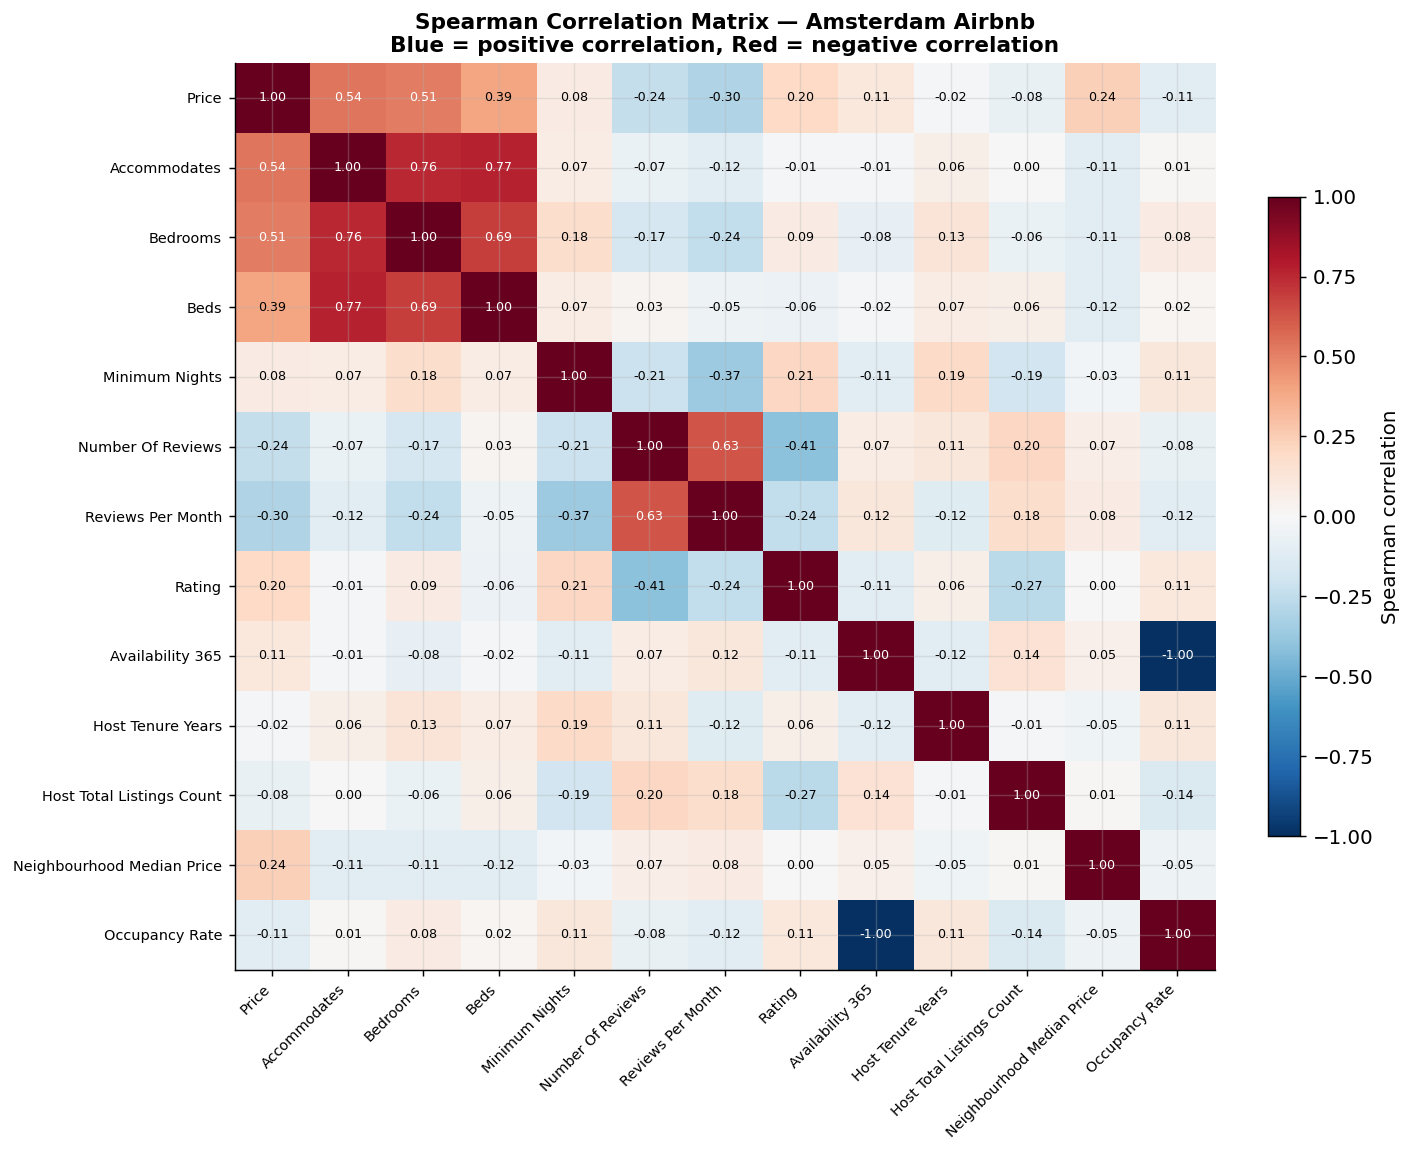

Strongest correlations with PRICE (Spearman):
---------------------------------------------
  accommodates                       : +0.537 (positive)
  bedrooms                           : +0.513 (positive)
  beds                               : +0.391 (positive)
  reviews_per_month                  : -0.301 (negative)
  number_of_reviews                  : -0.240 (negative)
  neighbourhood_median_price         : +0.237 (positive)
  review_scores_rating               : +0.198 (positive)
  occupancy_rate                     : -0.109 (negative)

Why Spearman not Pearson correlation?
  Pearson assumes a linear relationship between two normally distributed variables.
  Spearman uses RANKS instead of raw values — it works correctly on skewed data
  like price, and detects monotonic relationships (consistently higher/lower)
  even if they are not perfectly linear.



In [12]:
# Select numeric columns for correlation
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'availability_365',
    'host_tenure_years', 'host_total_listings_count',
    'neighbourhood_median_price', 'occupancy_rate'
]
corr_cols = [c for c in corr_cols if c in valid.columns]
corr_df   = valid[corr_cols].dropna()

corr_matrix = corr_df.corr(method='spearman')  # Spearman — robust to outliers and skew

fig, ax = plt.subplots(figsize=(11, 9))

# Manual heatmap for clean display
import matplotlib.colors as mcolors
cmap = plt.cm.RdBu_r
im   = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, label='Spearman correlation')

labels = [c.replace('_', ' ').replace('review scores ', '').title()
          for c in corr_matrix.columns]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Add correlation values in cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_title('Spearman Correlation Matrix — Amsterdam Airbnb\n'
             'Blue = positive correlation, Red = negative correlation',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'fig_16_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with price
price_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)
print('Strongest correlations with PRICE (Spearman):')
print('-' * 45)
for col, corr_val in price_corr.head(8).items():
    direction = 'positive' if corr_matrix.loc[col, 'price'] > 0 else 'negative'
    print(f'  {col:<35}: {corr_matrix.loc[col,"price"]:>+.3f} ({direction})')

print("""
Why Spearman not Pearson correlation?
  Pearson assumes a linear relationship between two normally distributed variables.
  Spearman uses RANKS instead of raw values — it works correctly on skewed data
  like price, and detects monotonic relationships (consistently higher/lower)
  even if they are not perfectly linear.
""")

In [13]:
# OLS Regression — quantify the marginal impact of each feature on price
# Using log(price) because price is skewed — see Section 4 notes

print('OLS Regression — What drives price? (log-transformed)')
print('=' * 60)

reg_df = valid.copy()

# Encode categorical variables
reg_df['is_entire_home'] = (reg_df['room_type'] == 'Entire home/apt').astype(int)
reg_df['is_private_room'] = (reg_df['room_type'] == 'Private room').astype(int)
reg_df['is_superhost']   = (reg_df['host_is_superhost'] == True).astype(int)

feature_cols = [
    'accommodates', 'bedrooms', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating',
    'is_entire_home', 'is_private_room', 'is_superhost',
    'host_tenure_years', 'neighbourhood_median_price',
    'availability_365'
]
feature_cols = [c for c in feature_cols if c in reg_df.columns]

model_df = reg_df[feature_cols + ['price']].dropna()
model_df['log_price'] = np.log1p(model_df['price'])

X = sm.add_constant(model_df[feature_cols])
y = model_df['log_price']

ols_model  = sm.OLS(y, X).fit()

print(f'\nModel fit: R-squared = {ols_model.rsquared:.3f}')
print(f'This means the features explain {ols_model.rsquared*100:.1f}% of price variation.')
print()
print(f'{"Feature":<30} {"Coefficient":>12} {"p-value":>10} {"Significant":>12}')
print('-' * 70)
for feat in feature_cols:
    coef = ols_model.params[feat]
    pv   = ols_model.pvalues[feat]
    sig  = 'YES' if pv < 0.05 else 'NO'
    # Interpret coefficient: in log model, coef = % change in price per unit
    pct_effect = (np.exp(coef) - 1) * 100
    print(f'{feat:<30} {coef:>+12.4f} {pv:>10.4f} {sig:>12}')
print()
print('Coefficient interpretation (log model):')
print('  Coefficient = log-unit change in price per 1-unit increase in the feature')
print('  Example: is_entire_home coef = 0.4 means entire homes cost e^0.4 = 1.49x more')
print('  (i.e. approximately 49% higher price) compared to the baseline room type')

OLS Regression — What drives price? (log-transformed)

Model fit: R-squared = 0.485
This means the features explain 48.5% of price variation.

Feature                         Coefficient    p-value  Significant
----------------------------------------------------------------------
accommodates                        +0.1212     0.0000          YES
bedrooms                            +0.1333     0.0000          YES
minimum_nights                      -0.0036     0.0000          YES
number_of_reviews                   -0.0003     0.0000          YES
review_scores_rating                +0.1588     0.0000          YES
is_entire_home                      -0.0488     0.4176           NO
is_private_room                     -0.4351     0.0000          YES
is_superhost                        +0.0309     0.0273          YES
host_tenure_years                   -0.0082     0.0000          YES
neighbourhood_median_price          +0.0059     0.0000          YES
availability_365                    +0

In [14]:
# Multicollinearity check — VIF
# VIF > 5 means a feature is highly correlated with others — unreliable coefficient
# VIF > 10 means serious multicollinearity — consider removing the feature

print('Multicollinearity Check — Variance Inflation Factor (VIF)')
print('=' * 55)
print('Rule: VIF < 5 = acceptable, VIF 5-10 = moderate, VIF > 10 = problematic')
print()

X_vif = model_df[feature_cols].dropna()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()  # standardize for VIF
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i+1)
                        for i in range(len(feature_cols))]
vif_data = vif_data.sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = '*** HIGH' if row['VIF'] > 10 else ('* moderate' if row['VIF'] > 5 else '')
    print(f'  {row["Feature"]:<30}: VIF = {row["VIF"]:>6.2f}  {flag}')

high_vif = vif_data[vif_data['VIF'] > 5]
print()
if len(high_vif) > 0:
    print(f'Features with VIF > 5: {high_vif["Feature"].tolist()}')
    print('These features are correlated with each other.')
    print('Individual coefficients may be unreliable, but the model predictions remain valid.')
    print('Example: bedrooms and accommodates are naturally correlated — bigger places have more beds AND more guests.')
else:
    print('No serious multicollinearity detected — all coefficients are reliable.')

Multicollinearity Check — Variance Inflation Factor (VIF)
Rule: VIF < 5 = acceptable, VIF 5-10 = moderate, VIF > 10 = problematic

  is_entire_home                : VIF =  21.34  *** HIGH
  is_private_room               : VIF =  20.80  *** HIGH
  bedrooms                      : VIF =   2.30  
  accommodates                  : VIF =   2.23  
  number_of_reviews             : VIF =   1.31  
  is_superhost                  : VIF =   1.27  
  review_scores_rating          : VIF =   1.08  
  host_tenure_years             : VIF =   1.07  
  availability_365              : VIF =   1.06  
  neighbourhood_median_price    : VIF =   1.03  
  minimum_nights                : VIF =   1.02  

Features with VIF > 5: ['is_entire_home', 'is_private_room']
These features are correlated with each other.
Individual coefficients may be unreliable, but the model predictions remain valid.
Example: bedrooms and accommodates are naturally correlated — bigger places have more beds AND more guests.


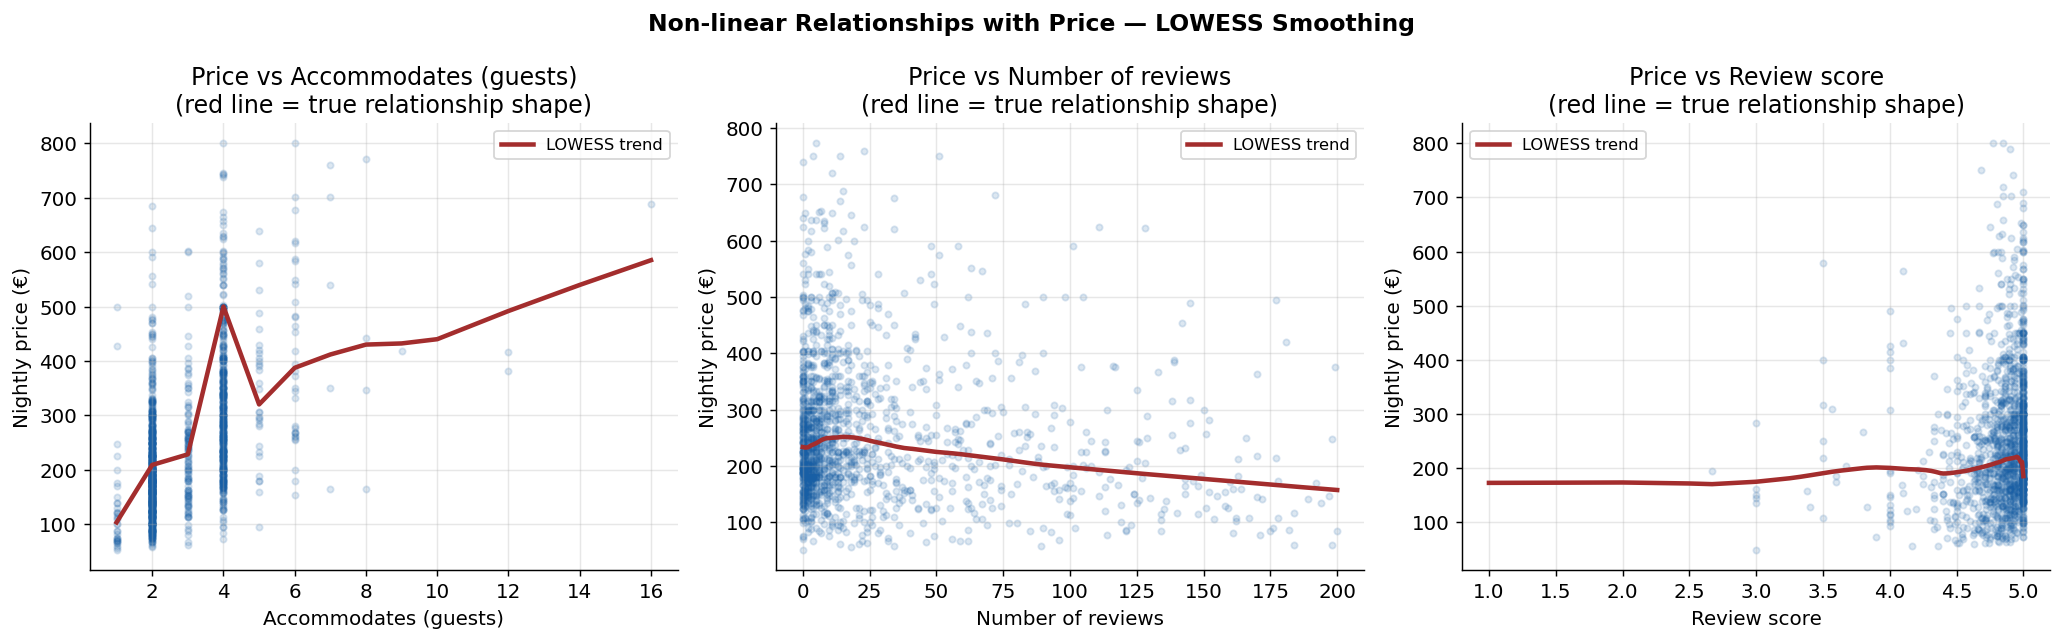


What LOWESS shows us:

  ACCOMMODATES vs PRICE:
  The relationship is not a straight line. Price rises with capacity
  but flattens or even dips for very large properties. Very large listings
  (10+ guests) may be priced lower per person than medium-sized ones.

  REVIEWS vs PRICE:
  New listings (0-20 reviews) show a wide price range — hosts are still
  figuring out optimal pricing. After 50+ reviews, prices stabilize
  slightly higher — confirmed demand allows more confident pricing.

  REVIEW SCORE vs PRICE:
  Below 4.5 there is little relationship — low-rated listings exist
  at all price points. Above 4.8, there is a slight upward trend.
  This confirms that rating alone is not a strong price predictor.

Why this matters for the ML model:
  A linear regression assumes straight-line relationships everywhere.
  LOWESS reveals these are NOT all straight lines.
  XGBoost handles non-linear relationships automatically — this is
  one reason tree-based models outperform linear regressi

In [15]:
# Non-linear relationships — scatter plots with LOWESS curves
# LOWESS = locally weighted smoothing — shows the true shape of the relationship
# without assuming it is a straight line

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Non-linear Relationships with Price — LOWESS Smoothing',
             fontsize=13, fontweight='bold')

plot_pairs = [
    ('accommodates',       'Accommodates (guests)',         axes[0]),
    ('number_of_reviews',  'Number of reviews',             axes[1]),
    ('review_scores_rating','Review score',                 axes[2]),
]

for col, xlabel, ax in plot_pairs:
    if col not in valid.columns:
        continue
    plot_df = valid[[col, 'price']].dropna()
    plot_df = plot_df[plot_df['price'] <= 800]  # cap for readability
    if col == 'number_of_reviews':
        plot_df = plot_df[plot_df[col] <= 200]

    sample = plot_df.sample(min(1500, len(plot_df)), random_state=42)

    ax.scatter(sample[col], sample['price'],
               alpha=0.15, color=BLUE, s=12)

    # LOWESS curve
    lowess = sm.nonparametric.lowess(
        plot_df['price'], plot_df[col], frac=0.3
    )
    ax.plot(lowess[:, 0], lowess[:, 1],
            color=RED, linewidth=2.5, label='LOWESS trend')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Nightly price (€)')
    ax.set_title(f'Price vs {xlabel}\n(red line = true relationship shape)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS / 'fig_17_nonlinear_relationships.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""
What LOWESS shows us:

  ACCOMMODATES vs PRICE:
  The relationship is not a straight line. Price rises with capacity
  but flattens or even dips for very large properties. Very large listings
  (10+ guests) may be priced lower per person than medium-sized ones.

  REVIEWS vs PRICE:
  New listings (0-20 reviews) show a wide price range — hosts are still
  figuring out optimal pricing. After 50+ reviews, prices stabilize
  slightly higher — confirmed demand allows more confident pricing.

  REVIEW SCORE vs PRICE:
  Below 4.5 there is little relationship — low-rated listings exist
  at all price points. Above 4.8, there is a slight upward trend.
  This confirms that rating alone is not a strong price predictor.

Why this matters for the ML model:
  A linear regression assumes straight-line relationships everywhere.
  LOWESS reveals these are NOT all straight lines.
  XGBoost handles non-linear relationships automatically — this is
  one reason tree-based models outperform linear regression on this data.
""")